# YOLOv8n Pothole Detection Model Testing

This notebook tests the pretrained YOLOv8n model on pothole detection data from the Pothole_Segmentation_YOLOv8 dataset.

## Section 1: Set Up the Environment and Imports

Import necessary libraries and verify that required packages are installed.

In [53]:
import os
import sys
from pathlib import Path
import glob
import json
from datetime import datetime

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

# Check and install ultralytics if needed
try:
    from ultralytics import YOLO
    print("✓ Ultralytics YOLO library is installed")
except ImportError:
    print("Installing ultralytics...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ultralytics"])
    from ultralytics import YOLO
    print("✓ Ultralytics YOLO installed successfully")

# Check for PIL
try:
    from PIL import Image
    print("✓ PIL library is installed")
except ImportError:
    print("Installing Pillow...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "Pillow"])
    from PIL import Image
    print("✓ Pillow installed successfully")

print("\n✓ All required libraries imported successfully!")

✓ Ultralytics YOLO library is installed
✓ PIL library is installed

✓ All required libraries imported successfully!


## Setup Device Configuration

Configure the inference device (CPU recommended for compatibility).

In [54]:
import torch

# Configure device - Use CPU for maximum compatibility
# (GPU/CUDA can have compatibility issues with torchvision NMS operations)
DEVICE = 'cpu'

# Optional: Check if CUDA is available (for reference)
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

# Set device globally
torch.device(DEVICE)
print("✓ Device configured successfully!\n")

CUDA available: True
Using device: cpu
PyTorch version: 2.5.1+cu121
✓ Device configured successfully!



## Section 2: Inspect the Pothole_Segmentation_YOLOv8 Folder Structure

Set the project root and explore the directory structure to locate data files.

In [55]:
# Set project root to the current Pothole_Segmentation_YOLOv8 folder
PROJECT_ROOT = Path.cwd()
print(f"Project Root: {PROJECT_ROOT}\n")

# Display folder structure
print("📁 Folder Structure:")
print("=" * 60)

for root, dirs, files in os.walk(PROJECT_ROOT):
    # Skip certain directories to keep output clean
    dirs[:] = [d for d in dirs if d not in ['.git', '__pycache__', '.ipynb_checkpoints']]
    
    level = root.replace(str(PROJECT_ROOT), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Show first 5 files per directory
        print(f"{subindent}{file}")
    
    if len(files) > 5:
        print(f"{subindent}... and {len(files) - 5} more files")

# Look for key files
print("\n" + "=" * 60)
print("🔍 Key Files Found:")
print("=" * 60)

data_yaml = list(PROJECT_ROOT.glob("**/data.yaml"))
if data_yaml:
    print(f"✓ data.yaml found: {data_yaml[0]}")

pt_files = list(PROJECT_ROOT.glob("**/*.pt"))
for pt in pt_files:
    print(f"✓ Model file: {pt.name}")

# Check for images
image_dirs = {
    "train": list(PROJECT_ROOT.glob("train/images/*")),
    "valid": list(PROJECT_ROOT.glob("valid/images/*")),
}

for split, images in image_dirs.items():
    if images:
        print(f"✓ {split.capitalize()} images: {len(images)} files")

Project Root: e:\6th SEM Data\Projects\AEGIS-RS_IDP\Pothole_Segmentation_YOLOv8

📁 Folder Structure:
Pothole_Segmentation_YOLOv8/
  data.yaml
  README.dataset.txt
  README.roboflow.txt
  sample_video.mp4
  test_yolov8n.ipynb
  ... and 3 more files
  inference_results/
    predictions_20260507_203639.png
    predictions_20260507_203646.json
    predictions_20260507_203754.png
    predictions_20260507_203801.json
    predictions_20260507_204143.png
    ... and 10 more files
  runs/
    detect/
      train/
        args.yaml
        labels.jpg
        results.csv
        train_batch0.jpg
        train_batch1.jpg
        ... and 1 more files
        weights/
          best.pt
          last.pt
      train2/
        args.yaml
        weights/
      train3/
        args.yaml
        weights/
      train4/
        args.yaml
        weights/
      train5/
        args.yaml
        weights/
      train6/
        args.yaml
        labels.jpg
        train_batch0.jpg
        train_batch1.jpg
    

## Section 3: Load yolov8n.pt with Ultralytics YOLO

Load the pretrained YOLOv8n model from the local directory.

In [56]:
# Find and load the yolov8n.pt model
model_path = PROJECT_ROOT / r"runs\detect\train7\weights\best.pt"

if model_path.exists():
    print(f"✓ Model file found: {model_path}")
    model = YOLO(str(model_path))
    print(f"✓ Model loaded successfully!")
    print(f"  Model type: {model.model.model_info() if hasattr(model.model, 'model_info') else type(model.model)}")
else:
    print(f"✗ Model file not found at {model_path}")
    # Try to find any .pt file
    pt_files = list(PROJECT_ROOT.glob("*.pt"))
    if pt_files:
        print(f"Found .pt files: {pt_files}")
        model_path = pt_files[0]
        model = YOLO(str(model_path))
        print(f"✓ Model loaded from: {model_path}")
    else:
        print("No .pt files found in the project directory!")
        model = None

if model is not None:
    print("\n✓ Model is ready for inference!")

✓ Model file found: e:\6th SEM Data\Projects\AEGIS-RS_IDP\Pothole_Segmentation_YOLOv8\runs\detect\train7\weights\best.pt
✓ Model loaded successfully!
  Model type: <class 'ultralytics.nn.tasks.DetectionModel'>

✓ Model is ready for inference!


## Section 4: Locate the Pothole Dataset Configuration or Images

Find dataset YAML configuration and image paths for inference and validation.

In [57]:
# Find data.yaml configuration
data_yaml_path = None
yaml_candidates = list(PROJECT_ROOT.glob("**/data.yaml"))

if yaml_candidates:
    data_yaml_path = yaml_candidates[0]
    print(f"✓ data.yaml found: {data_yaml_path}")
    
    # Read and display yaml content
    with open(data_yaml_path, 'r') as f:
        yaml_content = f.read()
    print("\nData configuration:")
    print(yaml_content)
else:
    print("✗ data.yaml not found, will manually set paths")

# Find image directories
train_images_dir = PROJECT_ROOT / "train" / "images"
valid_images_dir = PROJECT_ROOT / "valid" / "images"
test_images_dir = PROJECT_ROOT / "test" / "images" if (PROJECT_ROOT / "test").exists() else None

print("\n📂 Image Directory Paths:")
print("=" * 60)

image_paths = {
    "train": train_images_dir,
    "valid": valid_images_dir,
    "test": test_images_dir
}

for split, img_path in image_paths.items():
    if img_path and img_path.exists():
        image_count = len(list(img_path.glob("*.*")))
        print(f"✓ {split.capitalize()}: {img_path} ({image_count} images)")
    elif img_path:
        print(f"✗ {split.capitalize()}: {img_path} (not found)")

# Get sample images for inference
sample_images = []
if valid_images_dir.exists():
    sample_images = sorted(list(valid_images_dir.glob("*.jpg")) + list(valid_images_dir.glob("*.png")))[:5]
    print(f"\n✓ Found {len(sample_images)} sample images for testing")
elif train_images_dir.exists():
    sample_images = sorted(list(train_images_dir.glob("*.jpg")) + list(train_images_dir.glob("*.png")))[:5]
    print(f"\n✓ Using {len(sample_images)} training images for testing")

✓ data.yaml found: e:\6th SEM Data\Projects\AEGIS-RS_IDP\Pothole_Segmentation_YOLOv8\data.yaml

Data configuration:
train: ../train/images
val: ../valid/images

nc: 1
names: ['Pothole']

roboflow:
  workspace: farzad
  project: pothole_segmentation_yolov8
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/farzad/pothole_segmentation_yolov8/dataset/1

📂 Image Directory Paths:
✓ Train: e:\6th SEM Data\Projects\AEGIS-RS_IDP\Pothole_Segmentation_YOLOv8\train\images (720 images)
✓ Valid: e:\6th SEM Data\Projects\AEGIS-RS_IDP\Pothole_Segmentation_YOLOv8\valid\images (60 images)

✓ Found 5 sample images for testing


## Section 5: Run Inference on Sample Pothole Images

Execute predictions on sample pothole images using the loaded yolov8n.pt model.

In [58]:
if model is None:
    print("✗ Model not loaded. Skipping inference.")
else:
    print(f"Running inference on {len(sample_images)} sample images...\n")
    
    # Run predictions on sample images
    results = []
    for img_path in sample_images:
        print(f"Predicting: {img_path.name}")
        result = model.predict(source=str(img_path), conf=0.25, iou=0.45, device=DEVICE, verbose=False)
        results.append({
            'image_path': str(img_path),
            'image_name': img_path.name,
            'result': result[0] if result else None
        })
    
    print(f"\n✓ Inference completed on {len(results)} images!")
    
    # Display inference statistics
    print("\n📊 Inference Statistics:")
    print("=" * 60)
    for i, pred_data in enumerate(results):
        result = pred_data['result']
        if result is not None:
            num_detections = len(result.boxes) if result.boxes is not None else 0
            print(f"{i+1}. {pred_data['image_name']}: {num_detections} objects detected")

Running inference on 5 sample images...

Predicting: pic-114-_jpg.rf.a0f30e06b3b96d7879d5f55a7012433c.jpg
Predicting: pic-116-_jpg.rf.ddcb9d0e0bcf2a1a5096c4f04e6b7f9e.jpg
Predicting: pic-123-_jpg.rf.385ae3fbcdabda81f72ddf11f6a4b93d.jpg
Predicting: pic-125-_jpg.rf.3d316e9144cb7438021e01065de91057.jpg
Predicting: pic-129-_jpg.rf.d307956eee8ac32fbe793335e87c7b67.jpg

✓ Inference completed on 5 images!

📊 Inference Statistics:
1. pic-114-_jpg.rf.a0f30e06b3b96d7879d5f55a7012433c.jpg: 1 objects detected
2. pic-116-_jpg.rf.ddcb9d0e0bcf2a1a5096c4f04e6b7f9e.jpg: 13 objects detected
3. pic-123-_jpg.rf.385ae3fbcdabda81f72ddf11f6a4b93d.jpg: 2 objects detected
4. pic-125-_jpg.rf.3d316e9144cb7438021e01065de91057.jpg: 12 objects detected
5. pic-129-_jpg.rf.d307956eee8ac32fbe793335e87c7b67.jpg: 1 objects detected


## Section 6: Visualize Predictions

Display predicted bounding boxes on sample images with visualization.


✓ Predictions visualization saved to: e:\6th SEM Data\Projects\AEGIS-RS_IDP\Pothole_Segmentation_YOLOv8\inference_results\predictions_20260507_204557.png


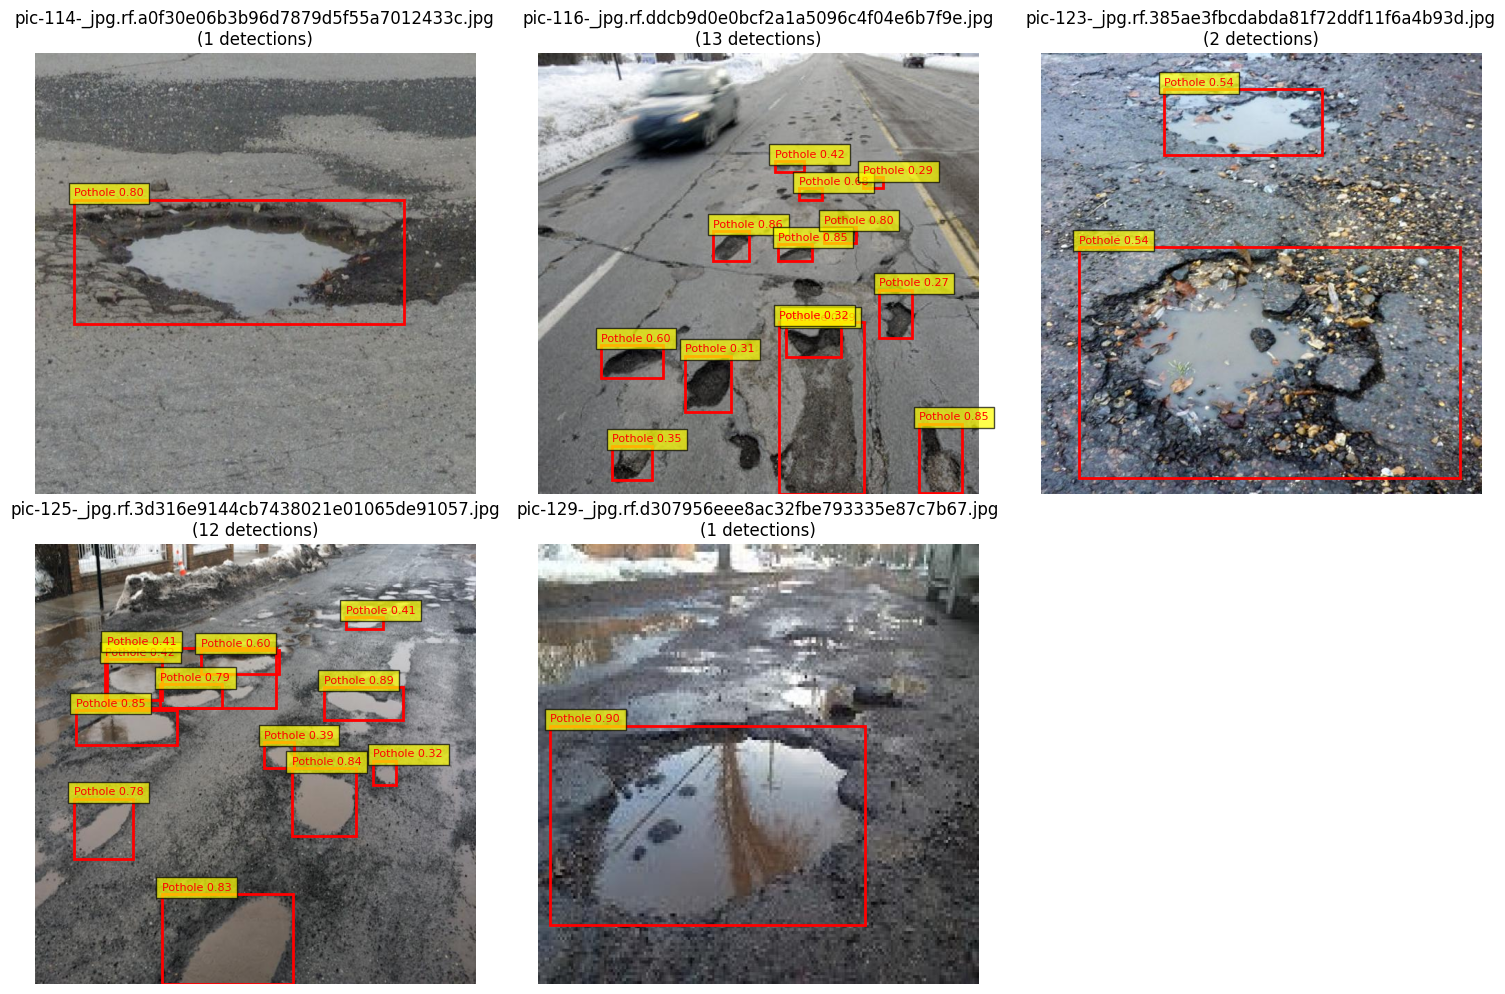

In [59]:
if model is None or len(results) == 0:
    print("✗ No results to visualize.")
else:
    # Create output directory
    output_dir = PROJECT_ROOT / "inference_results"
    output_dir.mkdir(exist_ok=True)
    
    # Visualize predictions
    n_images = len(results)
    fig_cols = min(3, n_images)
    fig_rows = (n_images + fig_cols - 1) // fig_cols
    
    fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(15, 5 * fig_rows))
    if n_images == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, (ax, pred_data) in enumerate(zip(axes, results)):
        img_path = pred_data['image_path']
        result = pred_data['result']
        image_name = pred_data['image_name']
        
        # Read and display image
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        
        # Draw detections
        if result is not None and result.boxes is not None:
            boxes = result.boxes
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                conf = box.conf[0] if box.conf is not None else 0
                cls_id = int(box.cls[0]) if box.cls is not None else 0
                
                # Draw bounding box
                rect = patches.Rectangle(
                    (x1, y1), x2-x1, y2-y1,
                    linewidth=2, edgecolor='r', facecolor='none'
                )
                ax.add_patch(rect)
                
                # Add label
                label_text = f"Pothole {conf:.2f}"
                ax.text(x1, y1-5, label_text, 
                       color='red', fontsize=8, 
                       bbox=dict(facecolor='yellow', alpha=0.7))
        
        ax.set_title(f"{image_name}\n({len(result.boxes) if result and result.boxes else 0} detections)")
        ax.axis('off')
    
    # Hide unused subplots
    for idx in range(len(results), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    # Save figure
    output_path = output_dir / f"predictions_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    plt.savefig(output_path, dpi=100, bbox_inches='tight')
    print(f"\n✓ Predictions visualization saved to: {output_path}")
    plt.show()

## Section 7: Evaluate on the Pothole Validation/Test Split

Run model validation on the pothole dataset and capture performance metrics.

In [60]:
if model is None:
    print("✗ Model not loaded. Skipping validation.")
elif data_yaml_path is None:
    print("⚠️  data.yaml not found. Running inference-based evaluation instead...\n")
    
    # Manual evaluation on validation images
    all_detections = 0
    all_images_processed = 0
    
    for split_name, split_dir in [("validation", valid_images_dir), ("training", train_images_dir)]:
        if split_dir and split_dir.exists():
            images = list(split_dir.glob("*.jpg")) + list(split_dir.glob("*.png"))
            
            print(f"\n📊 Evaluating on {split_name} set ({len(images)} images):")
            print("=" * 60)
            
            split_detections = 0
            for img in images[:20]:  # Evaluate on first 20 images
                result = model.predict(source=str(img), conf=0.25, device=DEVICE, verbose=False)
                if result and result[0].boxes:
                    num_detections = len(result[0].boxes)
                    split_detections += num_detections
                    all_detections += num_detections
                all_images_processed += 1
            
            avg_detections = split_detections / len(images[:20]) if len(images[:20]) > 0 else 0
            print(f"✓ Processed {len(images[:20])} {split_name} images")
            print(f"  Total detections: {split_detections}")
            print(f"  Average detections per image: {avg_detections:.2f}")
else:
    print(f"Running validation using data.yaml: {data_yaml_path}\n")
    
    try:
        # Run validation using the data.yaml
        metrics = model.val(data=str(data_yaml_path), device=DEVICE)
        
        print("\n✓ Validation completed!")
        print("\n📊 Validation Metrics:")
        print("=" * 60)
        
        # Display metrics
        if hasattr(metrics, 'results_dict'):
            for key, value in metrics.results_dict.items():
                print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")
        else:
            print("Metrics object:", metrics)
            
    except Exception as e:
        print(f"⚠️  Validation error: {e}")
        print("Falling back to inference-based evaluation...")

print("\n✓ Evaluation phase completed!")

Running validation using data.yaml: e:\6th SEM Data\Projects\AEGIS-RS_IDP\Pothole_Segmentation_YOLOv8\data.yaml

Ultralytics 8.4.28  Python-3.12.7 torch-2.5.1+cu121 CPU (11th Gen Intel Core i7-11800H @ 2.30GHz)
val: Fast image access  (ping: 0.10.0 ms, read: 722.8165.3 MB/s, size: 86.5 KB)
val: Scanning E:\6th SEM Data\Projects\AEGIS-RS_IDP\Pothole_Segmentation_YOLOv8\valid\labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2it/s 3.4s1.4s
                   all         60        201      0.639      0.722      0.723      0.454
Speed: 0.9ms preprocess, 45.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to E:\6th SEM Data\Projects\AEGIS-RS_IDP\Pothole_Segmentation_YOLOv8\runs\detect\val6

✓ Validation completed!

📊 Validation Metrics:
metrics/precision(B): 0.6390
metrics/recall(B): 0.7221
metrics/mAP50(B): 0.7227
metrics/mAP

## Section 8: Save Prediction Outputs and Metrics

Save prediction results, visualizations, and evaluation metrics for review.

In [61]:
# Create output directory if not exists
output_dir = PROJECT_ROOT / "inference_results"
output_dir.mkdir(exist_ok=True)

# Save detailed predictions to JSON
if len(results) > 0:
    predictions_data = []
    
    for pred_data in results:
        result = pred_data['result']
        image_entry = {
            'image_name': pred_data['image_name'],
            'image_path': pred_data['image_path'],
            'num_detections': len(result.boxes) if result and result.boxes else 0,
            'detections': []
        }
        
        if result and result.boxes:
            for i, box in enumerate(result.boxes):
                x1, y1, x2, y2 = map(float, box.xyxy[0])
                conf = float(box.conf[0]) if box.conf is not None else 0.0
                cls_id = int(box.cls[0]) if box.cls is not None else 0
                
                image_entry['detections'].append({
                    'detection_id': i,
                    'class_id': cls_id,
                    'class_name': 'pothole',
                    'confidence': conf,
                    'bbox': {'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2}
                })
        
        predictions_data.append(image_entry)
    
    # Save to JSON
    json_path = output_dir / f"predictions_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    with open(json_path, 'w') as f:
        json.dump(predictions_data, f, indent=2)
    
    print(f"✓ Predictions saved to: {json_path}")

# Create summary report
summary_report = {
    'test_timestamp': datetime.now().isoformat(),
    'model_path': str(model_path) if model else 'N/A',
    'total_images_tested': len(results),
    'output_directory': str(output_dir),
    'summary': {
        'total_detections': sum(len(r['result'].boxes) if r['result'] and r['result'].boxes else 0 for r in results),
        'average_detections_per_image': sum(len(r['result'].boxes) if r['result'] and r['result'].boxes else 0 for r in results) / len(results) if len(results) > 0 else 0
    }
}

report_path = output_dir / f"test_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(report_path, 'w') as f:
    json.dump(summary_report, f, indent=2)

print(f"✓ Test report saved to: {report_path}")

print("\n" + "=" * 60)
print("✅ TESTING COMPLETE!")
print("=" * 60)
print(f"📁 Output directory: {output_dir}")
print(f"📊 Total images tested: {len(results)}")
if len(results) > 0:
    total_detections = sum(len(r['result'].boxes) if r['result'] and r['result'].boxes else 0 for r in results)
    print(f"🎯 Total detections: {total_detections}")
    print(f"📈 Average detections per image: {total_detections/len(results):.2f}")
print("\n✓ All outputs saved successfully!")

✓ Predictions saved to: e:\6th SEM Data\Projects\AEGIS-RS_IDP\Pothole_Segmentation_YOLOv8\inference_results\predictions_20260507_204604.json
✓ Test report saved to: e:\6th SEM Data\Projects\AEGIS-RS_IDP\Pothole_Segmentation_YOLOv8\inference_results\test_report_20260507_204604.json

✅ TESTING COMPLETE!
📁 Output directory: e:\6th SEM Data\Projects\AEGIS-RS_IDP\Pothole_Segmentation_YOLOv8\inference_results
📊 Total images tested: 5
🎯 Total detections: 29
📈 Average detections per image: 5.80

✓ All outputs saved successfully!
